# **Eocene OIFS Data Generation & Sanity Check Notebook**

This notebook runs every step of the `EoceneOIFS` pipeline and performs
sanity-check plotting for each modified field.

## 0. Setup

In [1]:
import os
import xarray as xr
import numpy as np
from cdo import Cdo
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import tempfile
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from helper_functions import load_grib_var_spec, compare_maps, compare_maps_cl

from eocene.oifs.eoceneOIFS import EoceneOIFS

cdo = Cdo()


## 1. Instantiate EoceneOIFS
Modify paths as needed.

In [2]:
eocene = EoceneOIFS(
    idir="/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2",
    odir="/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2-EOC",
    herold="/lus/h2resw01/hpcperm/ecme3497/herold-et-al-2014/Supp",
    startdate="19900101"
)

## 2. Prepare Herold data products

In [3]:
landsea =xr.open_dataset(eocene.prepare_herold(flag="landsea_mask"))
orog     = xr.open_dataset(eocene.prepare_herold(flag="orography"))
sd_orog  = xr.open_dataset(eocene.prepare_herold(flag="sd_orography"))


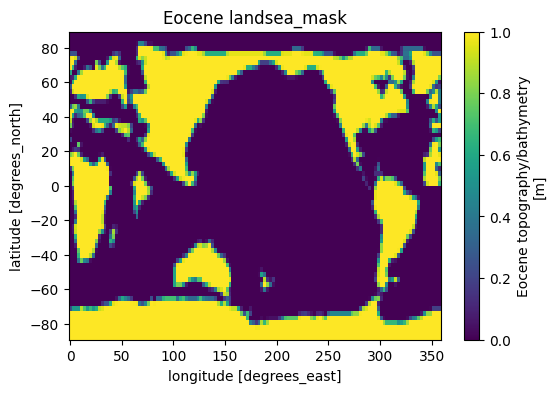

In [4]:
landsea_eocene = landsea["landsea_mask"]
plt.figure(figsize=(6,4))
landsea_eocene.plot()
plt.title("Eocene landsea_mask")
plt.show()

## 3. Prepare present-day land-sea mask (needed for albedo & vegetation)


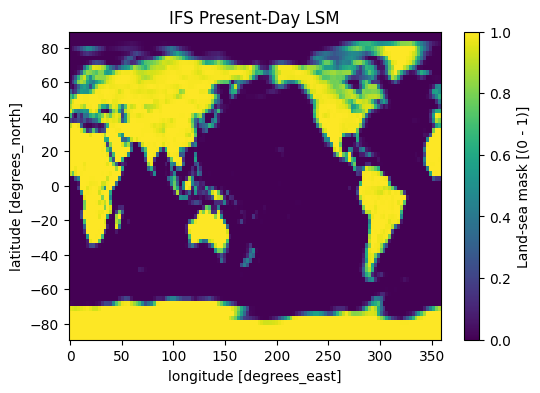

In [5]:
lsm_present = eocene.prepare_landsea_mask_present()
plt.figure(figsize=(6,4))
lsm_present.plot()
plt.title("IFS Present-Day LSM")
plt.show()


## 4. Run Eocene transformations


In [6]:
eocene.create_climate(lsm_present=lsm_present, landsea=landsea)
eocene.create_bare_soil(lsm_present=lsm_present, landsea=landsea)
eocene.create_sh(orog=orog['orography'])
eocene.create_init(lsm_present=lsm_present, landsea=landsea["landsea_mask"], sd_orog=sd_orog["sd_orography"])
eocene.create_iniua()
#eocene.create_sic()
#eocene.create_sst()
eocene.aerosols()


Converting to netcdf file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/oifs/TL63L31/climate.v020/ICMCLECE4
Modifying GRIB file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/oifs/TL63L31/climate.v020/ICMCLECE4 using function albedo
Applying combined Albedo reconstruction + Eocene mask...


/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/oifs/albedo.py:55: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntime = field.dims["time"]


Albedo reconstruction complete.
Eocene land-sea mask applied successfully.
Combined modification complete, GRIB structure preserved.
Converting back to GRIB file /etc/ecmwf/ssd/ssd1/tmpdirs/ecme3497.2660711.20260420_084032.143/cdoPyee1gwqsa
99990115
99990115
99990115
99990115
99990115
99990115
99990115
99990215
99990215
99990215
99990215
99990215
99990215
99990215
99990315
99990315
99990315
99990315
99990315
99990315
99990315
99990415
99990415
99990415
99990415
99990415
99990415
99990415
99990515
99990515
99990515
99990515
99990515
99990515
99990515
99990615
99990615
99990615
99990615
99990615
99990615
99990615
99990715
99990715
99990715
99990715
99990715
99990715
99990715
99990815
99990815
99990815
99990815
99990815
99990815
99990815
99990915
99990915
99990915
99990915
99990915
99990915
99990915
99991015
99991015
99991015
99991015
99991015
99991015
99991015
99991115
99991115
99991115
99991115
99991115
99991115
99991115
99991215
99991215
99991215
99991215
99991215
99991215
99991215
Con

/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/oifs/albedo.py:55: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntime = field.dims["time"]


Converting to netcdf file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/oifs/TL63L31/19900101/ICMSHECE4INIT
Modifying GRIB file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/oifs/TL63L31/19900101/ICMSHECE4INIT using function replace_value
Replacing variable z in the field
Converting back to GRIB file /etc/ecmwf/ssd/ssd1/tmpdirs/ecme3497.2660711.20260420_084032.143/cdoPyd43dzxbu
Converting to netcdf file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/oifs/TL63L31/19900101/ICMGGECE4INIT
Modifying GRIB file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/oifs/TL63L31/19900101/ICMGGECE4INIT using function replace_value
Replacing variable lsm in the field
Converting back to GRIB file /etc/ecmwf/ssd/ssd1/tmpdirs/ecme3497.2660711.20260420_084032.143/cdoPyww27xvcw
Converting to netcdf file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2-EOC/oifs/TL63L31/19900101/ICMGGECE4INIT
Modifying GRIB file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2-EOC/oifs/TL63L31/19900101/ICMGGECE4INIT using function vegetation_zhan

/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/oifs/albedo.py:55: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ntime = field.dims["time"]


Converting to netcdf file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/oifs/TL63L31/19900101/ICMGGECE4INIUA
Modifying GRIB file /lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2/oifs/TL63L31/19900101/ICMGGECE4INIUA using function modify_value
Modifying variable q in the field
Modifying variable crwc in the field
Modifying variable cswc in the field
Modifying variable clwc in the field
Modifying variable ciwc in the field
Modifying variable cc in the field
Converting back to GRIB file /etc/ecmwf/ssd/ssd1/tmpdirs/ecme3497.2660711.20260420_084032.143/cdoPypba3qwda


'/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2-EOC/oifs/ifsdata/aerosol_cams_climatology_43R3a.nc'

# 5. Sanity Checks

## ICMGGECE4INIT

In [7]:
orig = os.path.join(eocene.idir_init, "ICMGGECE4INIT")
new  = os.path.join(eocene.odir_init, "ICMGGECE4INIT")

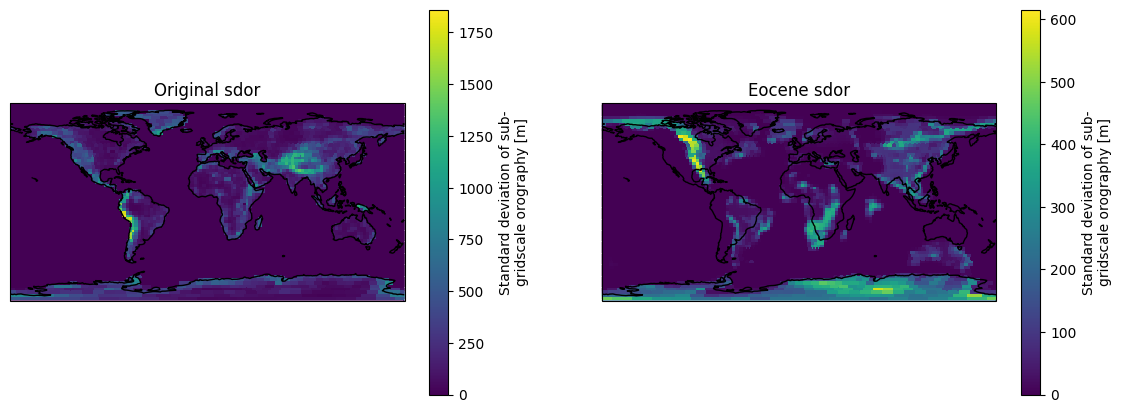

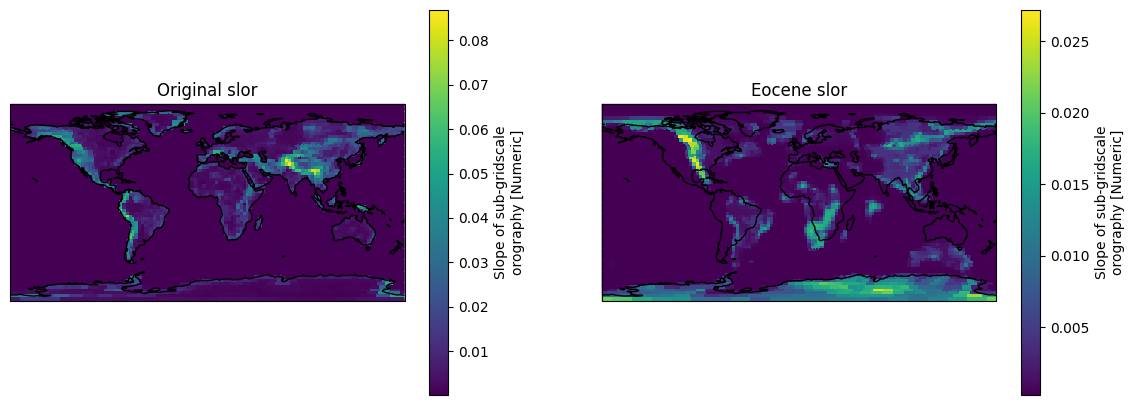

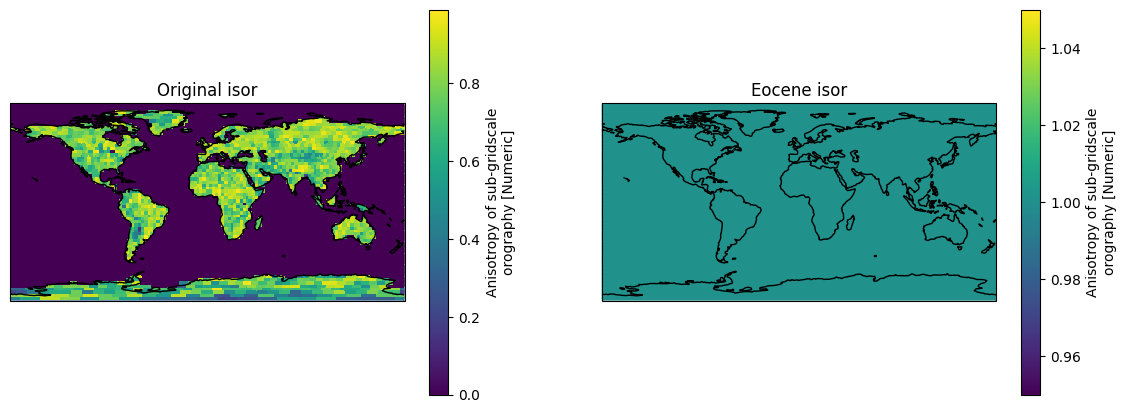

In [8]:
# Sub-grid orography
compare_maps("sdor", orig, new)   # subgrid orography
compare_maps("slor", orig, new)   # slope
compare_maps("isor", orig, new)   # anysotropy

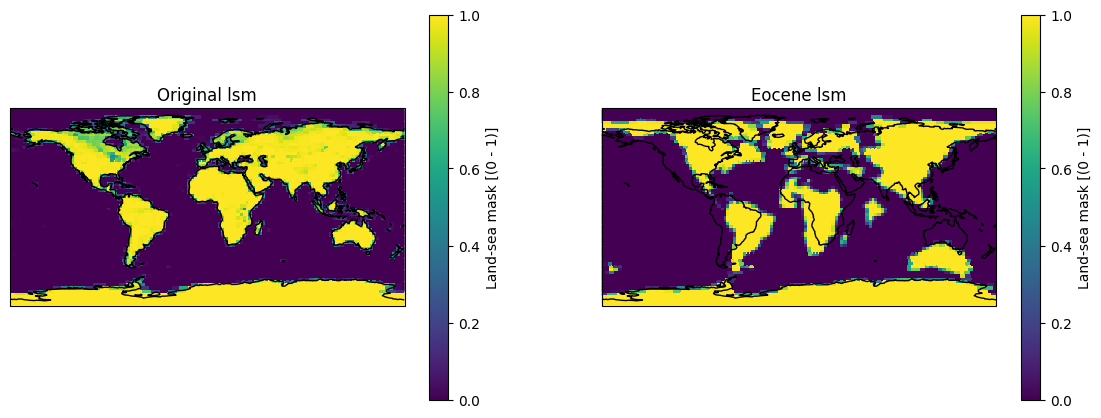

In [9]:
# Land-sea mask
compare_maps("lsm", orig, new)    # land-sea mask

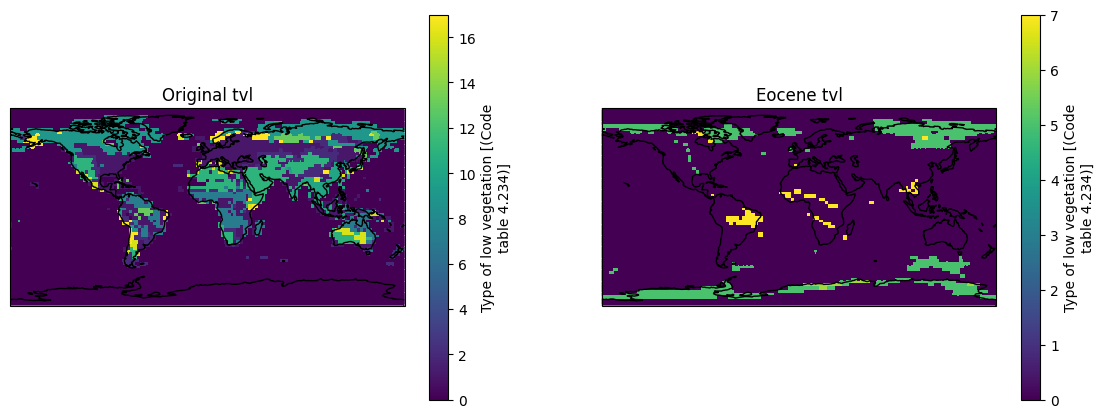

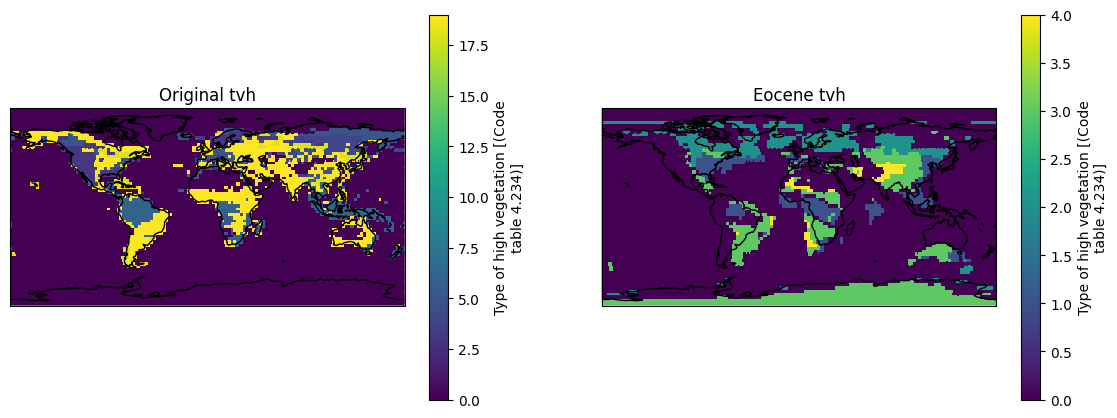

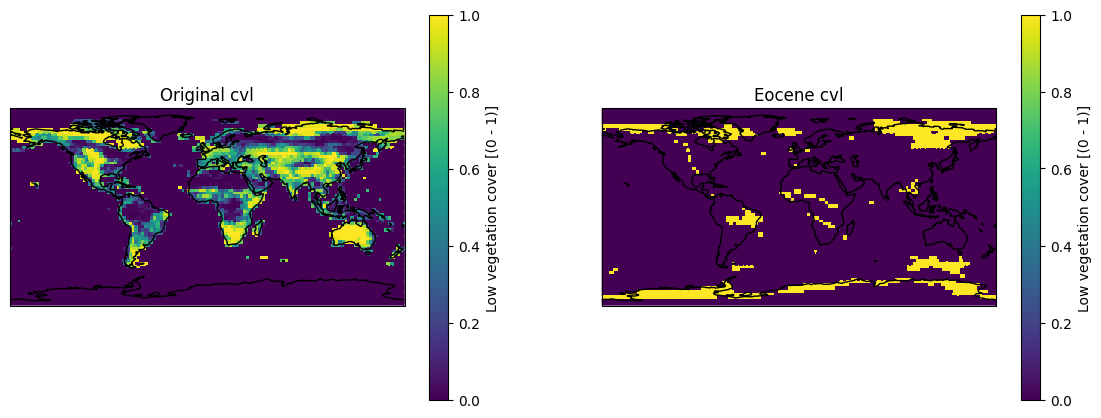

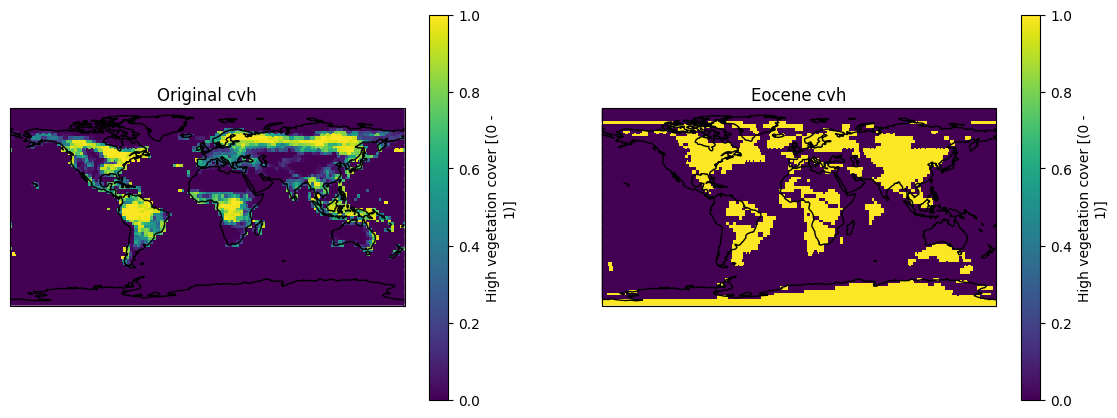

In [10]:
# Vegetation
compare_maps("tvl", orig, new)    # vegetation low
compare_maps("tvh", orig, new)    # vegetation high
compare_maps("cvl", orig, new)    # vegetation low
compare_maps("cvh", orig, new)    # vegetation high


## Vegetation

/perm/ecme3497/miniforge3/envs/eocene/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)
/perm/ecme3497/miniforge3/envs/eocene/lib/python3.14/site-packages/cartopy/mpl/geoaxes.py:291: UserWarning: The colormap's 'bad' has been set, but in order to wrap pcolormesh across the map it must be fully transparent.
  return func(self, *args, **kwargs)


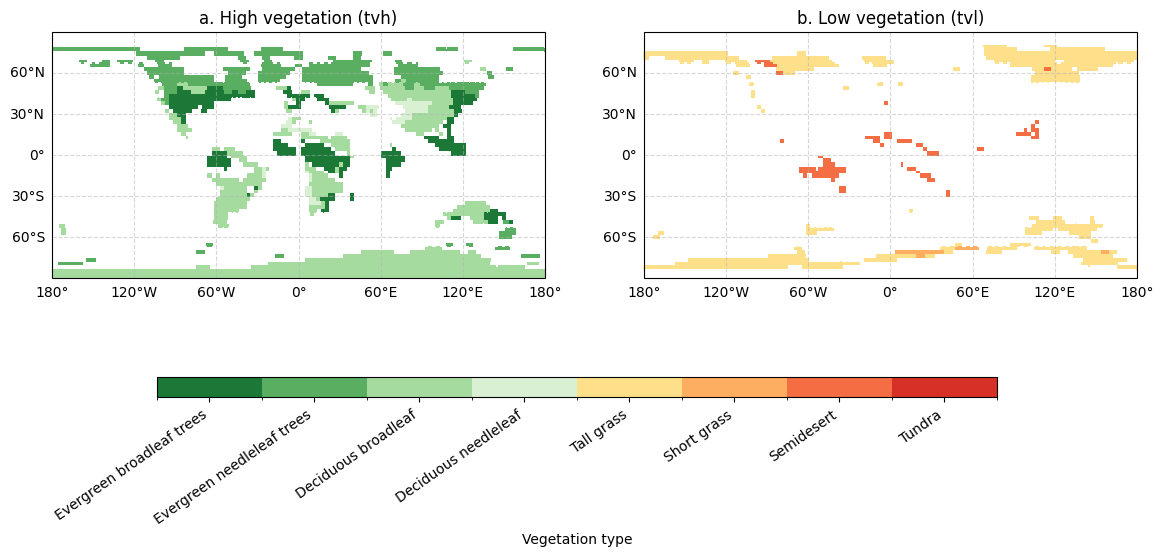

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm

def plot_veg_classes_cartopy(gribfile):

    tvl = load_grib_var_spec(gribfile, "tvl").squeeze()
    tvh = load_grib_var_spec(gribfile, "tvh").squeeze()
    lsm = load_grib_var_spec(gribfile, "lsm").squeeze()

    # mask ocean
    tvl = tvl.where(lsm > 0)
    tvh = tvh.where(lsm > 0)

    # mask "no vegetation" (0 values)
    tvl = tvl.where(tvl != 0)
    tvh = tvh.where(tvh != 0)

    # wrap longitude to -180 -> 180
    tvl = tvl.assign_coords(lon=((tvl.lon + 180) % 360) - 180).sortby("lon")
    tvh = tvh.assign_coords(lon=((tvh.lon + 180) % 360) - 180).sortby("lon")

    classes = [1,2,3,4,5,6,7,8]
    labels = {
        1: "Evergreen broadleaf trees",
        2: "Evergreen needleleaf trees",
        3: "Deciduous broadleaf",
        4: "Deciduous needleleaf",
        5: "Tall grass",
        6: "Short grass",
        7: "Semidesert",
        8: "Tundra"
    }

    colors = [
        "#1b7837", "#5aae61", "#a6dba0", "#d9f0d3",
        "#fee08b", "#fdae61", "#f46d43", "#d73027"
    ]

    cmap = ListedColormap(colors)
    cmap.set_bad("white")  # masked values appear white

    bounds = np.arange(0.5, 9.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        1, 2, figsize=(14,5),
        subplot_kw={"projection": proj}
    )

    # plot high vegetation
    im1 = tvh.plot(
        ax=axes[0],
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
        transform=proj
    )
    #axes[0].coastlines()
    axes[0].set_global()
    axes[0].set_title("a. High vegetation (tvh)")

    # plot low vegetation
    im2 = tvl.plot(
        ax=axes[1],
        cmap=cmap,
        norm=norm,
        add_colorbar=False,
        transform=proj
    )
    #axes[1].coastlines()
    axes[1].set_global()
    axes[1].set_title("b. Low vegetation (tvl)")

    # add gridlines with labels
    for ax in axes:
        gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}
        gl.xlocator = plt.FixedLocator(np.arange(-180, 181, 60))
        gl.ylocator = plt.FixedLocator(np.arange(-90, 91, 30))

    # horizontal colorbar
    fig.subplots_adjust(bottom=0.25)
    cax = fig.add_axes([0.2, 0.08, 0.6, 0.04])
    cbar = fig.colorbar(im2, cax=cax, orientation="horizontal")
    cbar.set_ticks(classes)
    cbar.set_ticklabels([labels[i] for i in classes])
    cbar.set_label("Vegetation type")
    cbar.ax.set_xticklabels([labels[i] for i in classes], rotation=35, ha="right")

    plt.show()


new = os.path.join(eocene.odir_init, "ICMGGECE4INIT")
plot_veg_classes_cartopy(new)


## ICMSHECE4INIT (Orography)

In [ ]:
#orig = os.path.join(eocene.idir_init, "ICMSHECE4INIT")
#new  = os.path.join(eocene.odir_init, "ICMSHECE4INIT")

#compare_maps("z", orig, new)   # geopotential

## ICMCLECE4 (climate fields)

/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/oifs/helper_functions.py:71: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(outfile)
/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/oifs/helper_functions.py:71: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(outfile)


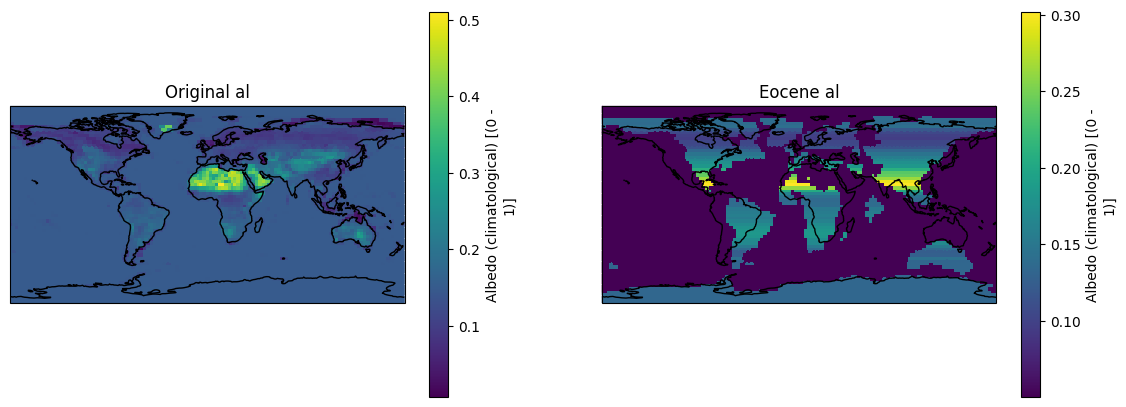

/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/oifs/helper_functions.py:71: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(outfile)
/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/oifs/helper_functions.py:71: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(outfile)


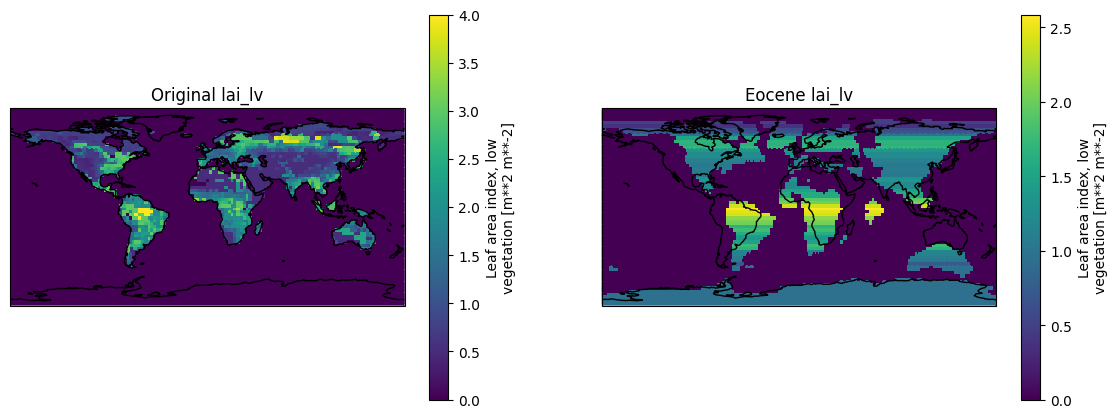

/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/oifs/helper_functions.py:71: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(outfile)
/lus/h2resw01/hpcperm/ecme3497/github/Eocene-creator/eocene/oifs/helper_functions.py:71: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  ds = xr.open_dataset(outfile)


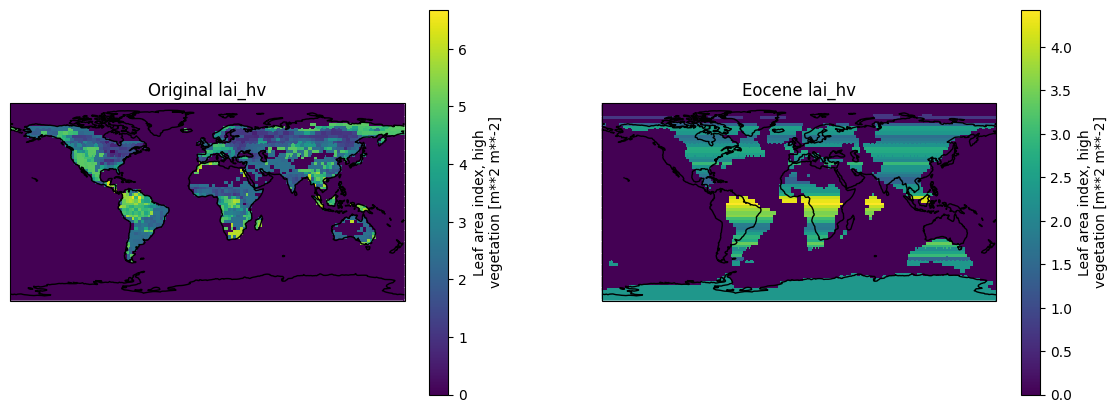

In [12]:
orig = os.path.join(eocene.idir_climate, "ICMCLECE4")
new  = os.path.join(eocene.odir_climate, "ICMCLECE4")

compare_maps_cl("al", orig, new)
compare_maps_cl("lai_lv", orig, new)
compare_maps_cl("lai_hv", orig, new)

## Aerosols

In [13]:
aerosols_ds = xr.open_dataset("/lus/h2resw01/hpcperm/ecme3497/ECE4-DATA-V2-EOC/oifs/ifsdata/aerosol_cams_climatology_43R3a.nc")

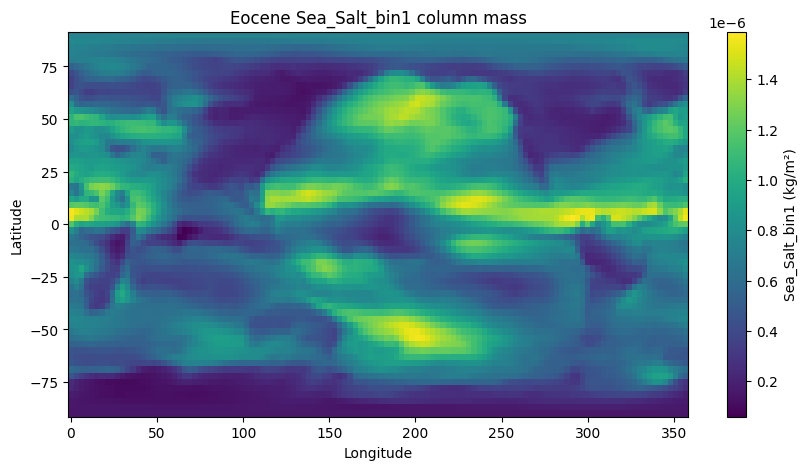

In [14]:
var_to_plot = 'Sea_Salt_bin1'
da = aerosols_ds[var_to_plot].isel(month=0)

plt.figure(figsize=(10,5))
im = plt.pcolormesh(da.lon, da.lat, da, shading='auto', cmap='viridis')
plt.colorbar(im, label=f"{var_to_plot} (kg/m²)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Eocene {var_to_plot} column mass")
plt.show()

In [15]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 20,        # base font
    "axes.titlesize": 28,   # title
    "axes.labelsize": 24,   # axis labels
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

In [16]:
# --- Sum all mineral dust bins ---
dust_total = aerosols_ds["Mineral_Dust_bin1"] + aerosols_ds["Mineral_Dust_bin2"] + aerosols_ds["Mineral_Dust_bin3"]

# --- Time mean if needed ---
if "month" in dust_total.dims:
    dust_mean = dust_total.mean(dim="month")
else:
    dust_mean = dust_total

# --- Add cyclic point for global map ---
dust_cyc, lon_cyc = add_cyclic_point(dust_mean, coord=dust_mean.lon)

/perm/ecme3497/miniforge3/envs/eocene/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


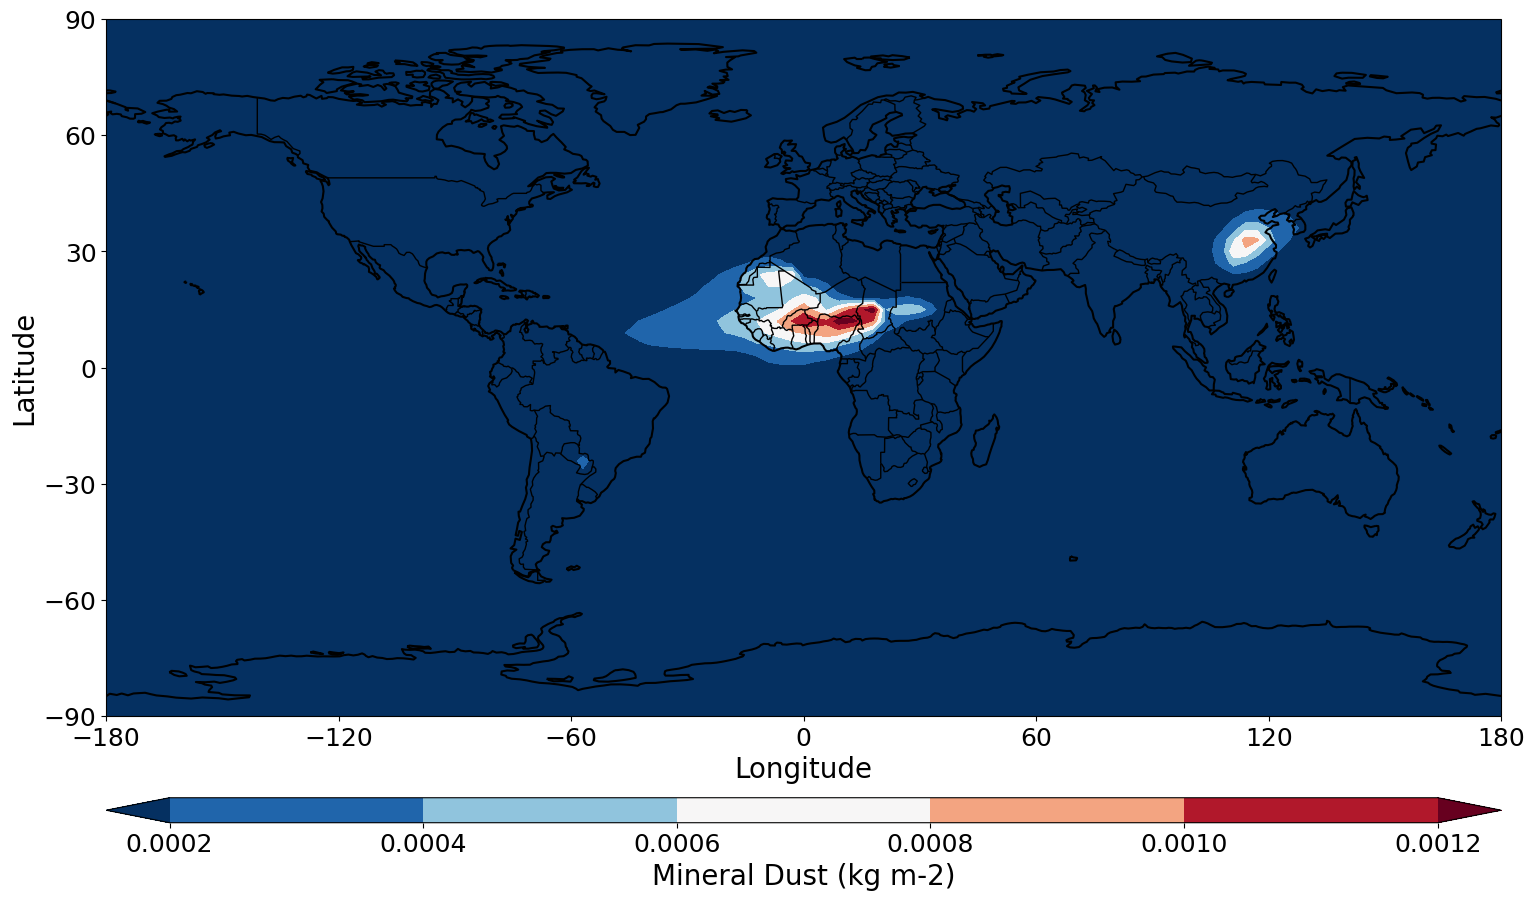

In [17]:
# --- Create figure ---
fig, ax = plt.subplots(
    figsize=(18, 10),
    dpi=100,
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# --- Plot ---
cf = ax.contourf(
    lon_cyc,
    dust_mean.lat,
    dust_cyc,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    extend="both"
)

# --- Map features ---
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.COASTLINE, color="black", linewidth=1.5)
ax.add_feature(cfeature.BORDERS, color="black", linewidth=1.0)

# --- Lat/Lon ticks ---
ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())

ax.set_xlabel("Longitude", fontsize=20)
ax.set_ylabel("Latitude", fontsize=20)
ax.tick_params(labelsize=18)

# --- Title ---
#ax.set_title("Total Mineral Dust", fontsize=26, fontweight="bold")

# --- Create separate colorbar axis ---
cax = fig.add_axes([0.125, 0.04, 0.775, 0.025])  
# [left, bottom, width, height] in figure coordinates

cbar = fig.colorbar(cf, cax=cax, orientation="horizontal")


units = dust_mean.attrs.get("units", "")
cbar.set_label(f"Mineral Dust ({units})", fontsize=20)
cbar.ax.tick_params(labelsize=18)

plt.show()